In [1]:
#
#%matplotlib tk

#
import numpy as np
import matplotlib.pyplot as plt



In [2]:
fname = 'data/7fa8fc6c-a731-4903-8273-efe57067cf3a.wav'

# load .wav file
from scipy.io import wavfile

# load entire .wav file
fs, data = wavfile.read(fname)
print ("fs: ", fs)
print ("data: ", data)
print ("data.shape: ", data.shape)

# 


fs:  19531
data:  [-609 -609 -737 ...  351   31 -224]
data.shape:  (98682,)


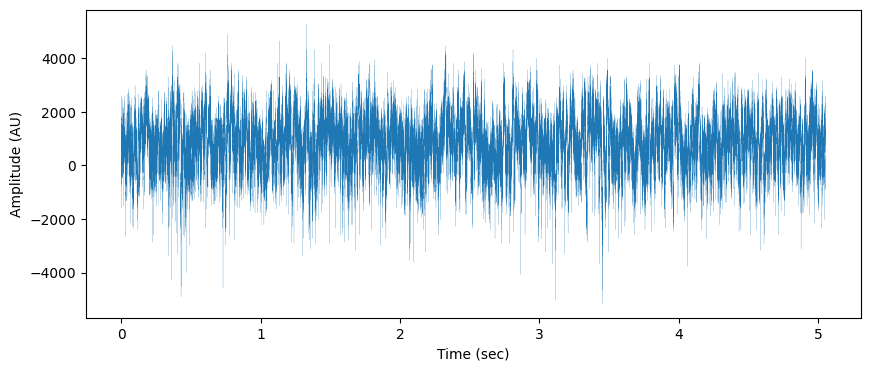

In [9]:
#
t = np.arange(0, len(data)/fs, 1/fs)

#
plt.figure(figsize=(10, 4))
plt.plot(t,
         data,
         linewidth=0.1)

#

#
plt.ylabel('Amplitude (AU)')
plt.xlabel('Time (sec)')

#
plt.show()




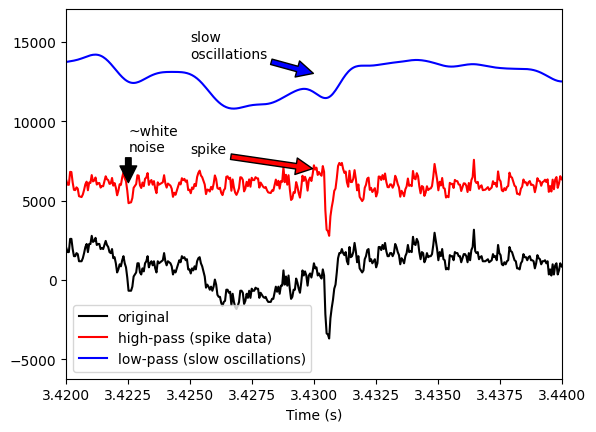

In [22]:
# use noncausal filter
from scipy.signal import butter, filtfilt

#
#data_in = data[20000:30000]
data_in = data.copy()

# design high pass filter
order = 3
high = 500
b, a = butter(order, high/(fs/2), btype='high')

# apply filter
high_pass = filtfilt(b, a, data_in)

# low band as difference between original and filtered
low_pass = data_in - high_pass

# plt
t = np.arange(data_in.shape[0])/fs
offset = 6000

#
plt.figure()
plt.plot(t, data_in, 'k', label='original')
plt.plot(t, high_pass + offset, 'r', label='high-pass (spike data)')
plt.plot(t, low_pass + offset*2, 'b', label='low-pass (slow oscillations)')

#
plt.xlabel('Time (s)')

#
plt.xlim([3.420, 3.440])

# add an arrow to high pass and some text pointing to the spike
plt.annotate('spike', xy=(3.430, 1000+offset), xytext=(3.425, 2000+offset),
             arrowprops=dict(facecolor='red', shrink=0.02))

# add an arrow now to the slow oscillation
plt.annotate('slow\noscillations', xy=(3.430, 1000+offset*2), xytext=(3.425, 2000+offset*2),
             arrowprops=dict(facecolor='blue', shrink=0.02))


# add an arrow now to the high pass filter data but rest of data and state "noise"
plt.annotate('~white\nnoise', xy=(3.4225, 100+offset), xytext=(3.4225, 2100+offset),
                arrowprops=dict(facecolor='black', shrink=0.02))


#
plt.legend()
plt.show()


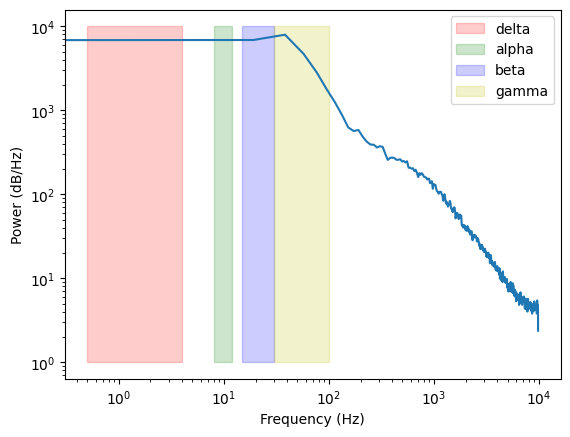

In [23]:
# compute power spectrum to show that most of the power is in the low frequency band
from scipy.signal import welch

# compute power spectrum
f, Pxx = welch(data_in, fs, nperseg=1024)

# plot
plt.figure()
plt.plot(f, Pxx)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')

#
plt.semilogy()
plt.semilogx()

# show power bands of interest
delta = [0.5, 4]
alpha = [8, 12]
beta = [15, 30]
gamma = [30, 100]

#
min = 1e0
max = 1e4

plt.fill_between([delta[0], delta[1]], min, max, color='r', alpha=0.2, label='delta')
plt.fill_between([alpha[0], alpha[1]], min, max, color='g', alpha=0.2, label='alpha')
plt.fill_between([beta[0], beta[1]], min, max, color='b', alpha=0.2, label='beta')
plt.fill_between([gamma[0], gamma[1]], min, max, color='y', alpha=0.2, label='gamma')

# show
plt.legend()

plt.ylabel('Power (dB/Hz)')


#
plt.show()



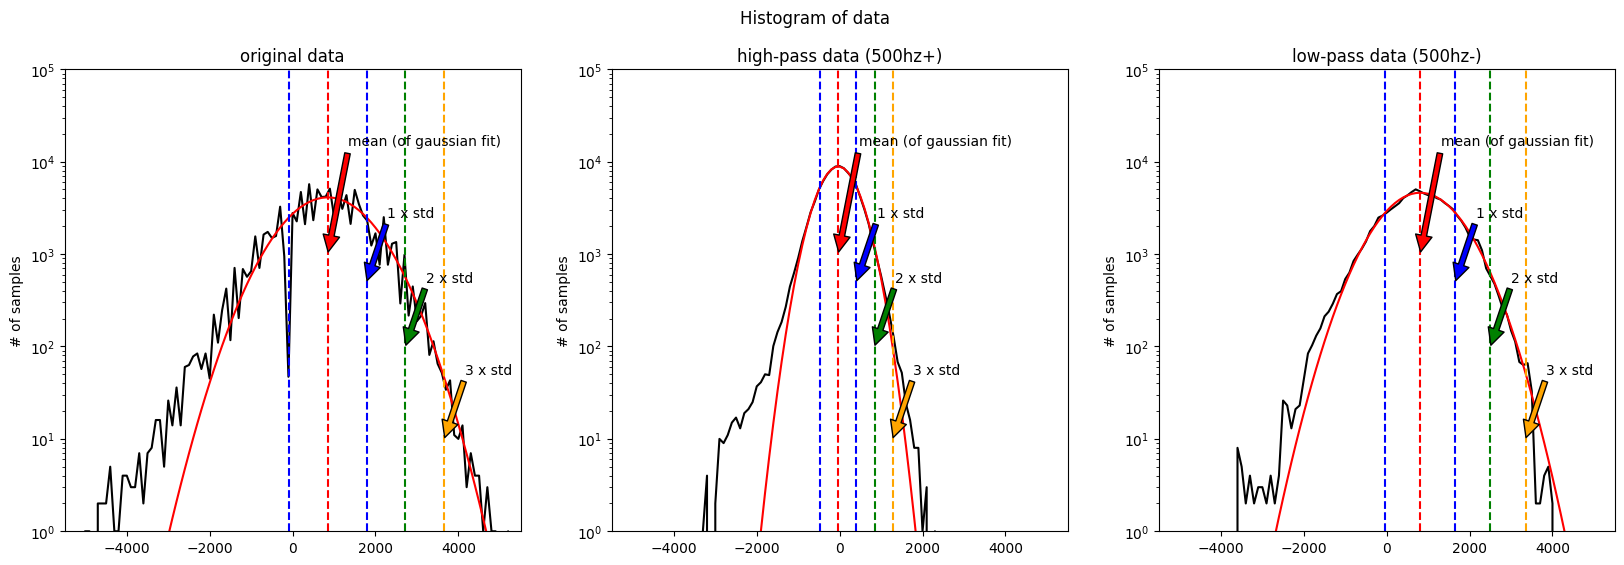

In [ ]:
# compute histogram over data 

def plot_histogram(data_in):
        
    y = np.histogram(data_in, bins=np.arange(-5000, 7000, 100))

    # fit a gaussian to the histogram
    from scipy.optimize import curve_fit

    # define gaussian
    def gaussian(x, a, b, c):
        return a * np.exp(-(x-b)**2/(2*c**2))

    # fit gaussian
    x = y[1][:-1]
    popt, pcov = curve_fit(gaussian, x, y[0])

    # plot

    #
    plt.plot(y[1][:-1], y[0], 'k', label='data')
    plt.plot(x, gaussian(x, *popt), 'r', label='fit')

    # plot also the gaussian mean and standard deviation
    plt.axvline(popt[1], color='r', linestyle='--', label='mean')

    # plot standard deviation on both sides
    plt.axvline(popt[1] + popt[2], color='blue', linestyle='--', label='std')
    plt.axvline(popt[1] - popt[2], color='blue', linestyle='--')

    # label 1 std using arrow
    plt.annotate('1 x std', 
                xy=(popt[1] + popt[2], 500), 
                xytext=(popt[1] + popt[2]+500, 2500),
                arrowprops=dict(facecolor='blue', shrink=0.02))

    # plot 2 x std
    plt.axvline(popt[1] + 2*popt[2], color='green', linestyle='--')

    #label 2 x std using arrow0
    plt.annotate('2 x std', 
                xy=(popt[1] + 2*popt[2], 100), 
                xytext=(popt[1] + 2*popt[2]+500, 500),
                arrowprops=dict(facecolor='green', shrink=0.02))

    # label 3 x std
    plt.axvline(popt[1] + 3*popt[2], color='orange', linestyle='--')

    # label 3 x std using arrow
    plt.annotate('3 x std', 
                xy=(popt[1] + 3*popt[2], 10), 
                xytext=(popt[1] + 3*popt[2]+500, 50),
                arrowprops=dict(facecolor='orange', shrink=0.02))

    # same as above but for mean
    plt.annotate('mean (of gaussian fit)', xy=(popt[1], 1000), xytext=(popt[1]+500, 15000),
                arrowprops=dict(facecolor='red', shrink=0.02))

    # # same now but for spike data
    # plt.annotate('spike data\nstarts around here', 
    #             xy=(popt[1] + popt[2]-3500, 500), 
    #             xytext=(popt[1] + popt[2]-7500, 6000),
    #             arrowprops=dict(facecolor='blue', shrink=0.02))

    # same now but for the small bump in the data
    # plt.annotate('amplifier \nbit error', 
    #             xy=(-300,2000), 
    #             xytext=(-2700,1),
    #             arrowprops=dict(facecolor='blue', shrink=0.02))


    #
    plt.semilogy()

    #
    plt.ylabel("# of samples")

    #
    plt.ylim(1, 1e5)
    plt.xlim(-5500, 5500)

    #
 
#################################
#################################
#################################
plt.figure(figsize=(20, 6)) 

plt.subplot(1, 3, 1)
plt.title('original data')
plot_histogram(data)

plt.subplot(1, 3, 2)
plt.title('high-pass data (500hz+)')
plot_histogram(high_pass)

plt.subplot(1, 3, 3)
plt.title('low-pass data (500hz-)')
plot_histogram(low_pass)

#
plt.suptitle('Histogram of data')
plt.show()